# VSP Vision — XGBoost Demand Forecasting and CLUSTER PREDICTION + DEMAND FORECASTING FOR 4 MONTHS
**Built on top of the fixed notebook — adds 8 new features + log-transform target**

| Version | R² (raw units) | R² (log scale) |
|---|---|---|
| Original notebook | 0.467 | — |
| Fixed notebook (your current) | 0.495 | — |
| **This notebook** | **~0.52** | **~0.68** |

> **Why two R² numbers?**  
> The model trains on `log(Sales+1)` to handle skewed sales distribution.  
> R² on log scale (~0.68) = how well the model predicts the *pattern*.  
> R² on raw units (~0.52) = how well it predicts actual unit counts.  
> Both are real — report the log-scale one as your primary metric since that's what the model optimizes.

## CELL 1 — Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

print('All imports successful')

All imports successful


## CELL 2 — Load Data

In [ ]:
demand     = pd.read_csv('final_demand.csv')
attributes = pd.read_csv('detailed_attributes.csv')

print('Demand shape:    ', demand.shape)
print('Attributes shape:', attributes.shape)

Demand shape:     (1464, 28)
Attributes shape: (220, 10)


## CELL 3 — Data Cleaning
*(unchanged from your fixed notebook)*

In [ ]:
demand.rename(columns={'Macro Region|Orig. Req. Deliv. Month/Year': 'Region'}, inplace=True)

case_cols = ['FrameShape', 'Gender', 'Material1', 'Material2', 'SunOptical', 'FrameConstruction']
for col in case_cols:
    if col in demand.columns:     demand[col]     = demand[col].str.title()
    if col in attributes.columns: attributes[col] = attributes[col].str.title()

demand['Size'] = demand['Size'].replace({3.0: 53.0, 5.0: 55.0})
demand = demand[demand['Size'] >= 40].copy()

monthly_cols = [
    '09/2023','10/2023','11/2023','12/2023',
    '01/2024','02/2024','03/2024','04/2024',
    '05/2024','06/2024','07/2024','08/2024'
]
demand[monthly_cols] = demand[monthly_cols].fillna(0)
demand['ColorDescription'] = demand['ColorDescription'].fillna('Unknown')

demand = demand.merge(
    attributes[['StyleCode', 'FrameConstruction', 'Material2']],
    on='StyleCode', how='left', suffixes=('', '_fill')
)
demand['FrameConstruction'] = demand['FrameConstruction'].fillna(demand['FrameConstruction_fill'])
demand['Material2']         = demand['Material2'].fillna(demand['Material2_fill'])
demand.drop(columns=['FrameConstruction_fill', 'Material2_fill'], inplace=True)

print(f'Shape after cleaning: {demand.shape}')
print(f'Nulls remaining: {demand.isnull().sum().sum()}')

Shape after cleaning: (1240, 28)
Nulls remaining: 0


## CELL 4 — Melt to Long Format
*(unchanged from your fixed notebook)*

In [ ]:
df_long = demand.melt(
    id_vars=[col for col in demand.columns if col not in monthly_cols],
    value_vars=monthly_cols,
    var_name='Month',
    value_name='Sales'
)
df_long['Month'] = pd.to_datetime(df_long['Month'], format='%m/%Y')
df_long = df_long.sort_values(['StyleCode', 'Region', 'Month']).reset_index(drop=True)

print(f'Long format shape: {df_long.shape}')
print(f'Date range: {df_long["Month"].min()} → {df_long["Month"].max()}')

Long format shape: (14880, 18)
Date range: 2023-09-01 00:00:00 → 2024-08-01 00:00:00


## CELL 5 — Feature Engineering ← UPGRADED
**8 new features added on top of your existing 5:**

| Feature | Type | Why it helps |
|---|---|---|
| `Lag_6` | Lag | Sales 6 months ago — medium-term trend |
| `Rolling_6mo_Avg` | Rolling | Smoother signal than 3-month alone — **#1 feature by importance** |
| `SKU_Max_Sales` | Expanding | Peak capacity of the SKU — ceiling reference |
| `Cumulative_Sales` | Expanding | How established is this SKU? New vs mature |
| `Sales_StdDev` | Rolling | How volatile is this SKU? |
| `MoM_Growth` | Derived | Is sales trend going up or down? |
| `Lag1_Brand_Avg` | Cross-SKU | Brand-level demand context |
| `SKU_vs_Brand_Avg` | Relative | Is this SKU above or below brand peers? |

In [ ]:
g = ['StyleCode', 'Region']

# ── Your existing lag features (unchanged) ──
df_long['Lag_1']           = df_long.groupby(g)['Sales'].shift(1)
df_long['Lag_2']           = df_long.groupby(g)['Sales'].shift(2)
df_long['Lag_3']           = df_long.groupby(g)['Sales'].shift(3)
df_long['Rolling_3mo_Avg'] = df_long.groupby(g)['Sales'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df_long['SKU_Avg_Sales']   = df_long.groupby(g)['Sales'].transform(
    lambda x: x.shift(1).expanding().mean())

# ── NEW: 8 additional features ──

# Lag 6 months back (longer memory)
df_long['Lag_6']            = df_long.groupby(g)['Sales'].shift(6)

# 6-month rolling average — smoother, more stable signal than 3-month
df_long['Rolling_6mo_Avg']  = df_long.groupby(g)['Sales'].transform(
    lambda x: x.shift(1).rolling(6, min_periods=1).mean())

# Peak sales this SKU has ever achieved (ceiling reference)
df_long['SKU_Max_Sales']    = df_long.groupby(g)['Sales'].transform(
    lambda x: x.shift(1).expanding().max().fillna(0))

# Total units sold so far (new SKU vs established SKU)
df_long['Cumulative_Sales'] = df_long.groupby(g)['Sales'].transform(
    lambda x: x.shift(1).cumsum().fillna(0))

# Sales volatility — high std = unpredictable SKU
df_long['Sales_StdDev']     = df_long.groupby(g)['Sales'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).std().fillna(0))

# Month-over-month growth rate (clipped to avoid outlier distortion)
df_long['MoM_Growth']       = df_long.groupby(g)['Sales'].transform(
    lambda x: x.shift(1).pct_change().fillna(0).clip(-2, 2))

# Brand-level monthly average (uses Lag_1 — no leakage)
df_long['Lag1_Brand_Avg']   = df_long.groupby(['Brand', 'Month'])['Lag_1'].transform('mean')

# How does this SKU rank vs brand peers last month?
df_long['SKU_vs_Brand_Avg'] = (
    df_long['Lag_1'] / df_long['Lag1_Brand_Avg'].replace(0, np.nan)
).fillna(1)

# ── Your existing time & price features (unchanged) ──
df_long['Month_Number']       = df_long['Month'].dt.month
df_long['Quarter']            = df_long['Month'].dt.quarter
df_long['Year']               = df_long['Month'].dt.year
df_long['Is_Peak_Season']     = df_long['Month_Number'].isin([1, 3, 4, 5]).astype(int)
df_long['LogPrice']           = np.log1p(df_long['USRetailPrice'])
df_long['MarginRatio']        = df_long['USWholesalePrice'] / df_long['USRetailPrice']
df_long['PriceTier']          = pd.cut(
    df_long['USRetailPrice'], bins=[0, 100, 150, 200, 300, 1000],
    labels=[1, 2, 3, 4, 5]).astype(float)
df_long['Price_vs_Brand_Avg'] = df_long['USRetailPrice'] / \
    df_long.groupby('Brand')['USRetailPrice'].transform('mean')
df_long['Is_Core_Size']       = df_long['Size'].between(52, 55).astype(int)

print(f'Total columns: {df_long.shape[1]}')
print(f'Features added vs previous notebook: +8 (Lag_6, Rolling_6mo, SKU_Max, Cumulative,')
print(f'                                         StdDev, MoM_Growth, Lag1_Brand_Avg, SKU_vs_Brand)')

Total columns: 40
Features added vs previous notebook: +8 (Lag_6, Rolling_6mo, SKU_Max, Cumulative,
                                         StdDev, MoM_Growth, Lag1_Brand_Avg, SKU_vs_Brand)


## CELL 6 — Drop, Clean, Encode
*(same as your fixed notebook)*

In [ ]:
drop_cols = [
    'Collection',       # redundant with Brand
    'ColorDescription', # too high cardinality, no signal
    'Material2',        # mostly same as Material1
    'StyleCode',        # identifier — causes leakage if kept
]
df_long = df_long.drop(columns=drop_cols, errors='ignore')
df_long = df_long.dropna(subset=['Lag_1', 'Lag_2', 'Lag_3'])

cat_cols = df_long.select_dtypes(include='object').columns.tolist()
print('Encoding:', cat_cols)
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_long[col] = le.fit_transform(df_long[col].astype(str))
    encoders[col] = le

df_long['RXAble'] = df_long['RXAble'].astype(int)

print(f'Final shape: {df_long.shape}')
print(f'Nulls: {df_long.isnull().sum().sum()}')

Encoding: ['Brand', 'Region', 'FrameConstruction', 'FrameShape', 'Gender', 'SunOptical', 'Material1']
Final shape: (14007, 36)
Nulls: 873


## CELL 7 — Train / Test Split + Log Transform Target
**NEW: `y_train_log` = `log(Sales+1)` — this is what all models will train on**

Why log-transform?
- Sales is heavily right-skewed: most SKUs sell ~50 units/month, some sell 1,000+
- Log transform compresses outliers so the model fits the full range better
- Always reverse with `np.expm1()` to get back to real units

In [ ]:
cutoff = pd.Timestamp('2024-06-01')

train = df_long[df_long['Month'] < cutoff]
test  = df_long[df_long['Month'] >= cutoff]

X_train = train.drop(columns=['Sales', 'Month', 'Total'], errors='ignore')
feature_names = X_train.columns
y_train = train['Sales']
X_test  = test.drop(columns=['Sales', 'Month', 'Total'], errors='ignore')
y_test  = test['Sales']

# Log-transform the target
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

print(f'Train: {len(X_train)} rows  (Sep 2023 → May 2024)')
print(f'Test:  {len(X_test)} rows   (Jun 2024 → Aug 2024)')
print(f'Features: {X_train.shape[1]}')
print(f'\nSales distribution (train): mean={y_train.mean():.0f}, std={y_train.std():.0f}, max={y_train.max():.0f}')
print(f'Log(Sales+1) distribution:  mean={y_train_log.mean():.2f}, std={y_train_log.std():.2f}')
print(f'\nFeature list:\n{X_train.columns.tolist()}')

Train: 10287 rows  (Sep 2023 → May 2024)
Test:  3720 rows   (Jun 2024 → Aug 2024)
Features: 33

Sales distribution (train): mean=63, std=80, max=1227
Log(Sales+1) distribution:  mean=3.14, std=1.77

Feature list:
['Brand', 'Region', 'Size', 'FrameConstruction', 'FrameShape', 'RXAble', 'Gender', 'SunOptical', 'Material1', 'USRetailPrice', 'USWholesalePrice', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_3mo_Avg', 'SKU_Avg_Sales', 'Lag_6', 'Rolling_6mo_Avg', 'SKU_Max_Sales', 'Cumulative_Sales', 'Sales_StdDev', 'MoM_Growth', 'Lag1_Brand_Avg', 'SKU_vs_Brand_Avg', 'Month_Number', 'Quarter', 'Year', 'Is_Peak_Season', 'LogPrice', 'MarginRatio', 'PriceTier', 'Price_vs_Brand_Avg', 'Is_Core_Size']


## CELL 8 — Baseline Comparison
All models trained on **log target**, evaluated on **both** scales

In [ ]:
from sklearn.impute import SimpleImputer

#feature_names = X_train.columns

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [ ]:
def evaluate(name, y_raw, preds_log_scale):
    preds_raw = np.clip(np.expm1(preds_log_scale), 0, None)
    r2_log = r2_score(np.log1p(y_raw), preds_log_scale)
    r2_raw = r2_score(y_raw, preds_raw)
    mae    = mean_absolute_error(y_raw, preds_raw)
    rmse   = np.sqrt(mean_squared_error(y_raw, preds_raw))
    mask   = y_raw > 0
    mape   = np.mean(np.abs((y_raw[mask] - preds_raw[mask]) / y_raw[mask])) * 100
    print(f'--- {name} ---')
    print(f'  R² (log scale): {r2_log:.4f}  ← primary metric')
    print(f'  R² (raw units): {r2_raw:.4f}')
    print(f'  MAE:  {mae:.2f} units')
    print(f'  RMSE: {rmse:.2f} units')
    print(f'  MAPE: {mape:.1f}%  (excl. zero-sales months)')
    print()
    return r2_log, r2_raw

# Linear Regression on log target
lr = LinearRegression()
lr.fit(X_train, y_train_log)
lr_preds = lr.predict(X_test)

# Random Forest on log target
rf = RandomForestRegressor(n_estimators=300, max_depth=15,
                           min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train_log)
rf_preds = rf.predict(X_test)

# XGBoost baseline on log target (no tuning)
xgb_base = XGBRegressor(n_estimators=300, learning_rate=0.05,
                        max_depth=6, random_state=42, n_jobs=-1)
xgb_base.fit(X_train, y_train_log)
xgb_base_preds = xgb_base.predict(X_test)

print('='*55)
print('BASELINE COMPARISON (all trained on log target)')
print('='*55)
evaluate('Linear Regression',    y_test, lr_preds)
evaluate('Random Forest',        y_test, rf_preds)
evaluate('XGBoost (no tuning)',  y_test, xgb_base_preds)

BASELINE COMPARISON (all trained on log target)
--- Linear Regression ---
  R² (log scale): 0.4164  ← primary metric
  R² (raw units): -18.0091
  MAE:  55.63 units
  RMSE: 337.32 units
  MAPE: 143.6%  (excl. zero-sales months)

--- Random Forest ---
  R² (log scale): 0.6809  ← primary metric
  R² (raw units): 0.5144
  MAE:  26.93 units
  RMSE: 53.91 units
  MAPE: 94.1%  (excl. zero-sales months)

--- XGBoost (no tuning) ---
  R² (log scale): 0.6784  ← primary metric
  R² (raw units): 0.5225
  MAE:  26.94 units
  RMSE: 53.46 units
  MAPE: 95.6%  (excl. zero-sales months)



(0.678411873504414, 0.5224642399645438)

## CELL 9 — Hyperparameter Tuning
- Tuning on **log scale** (consistent with what we train and evaluate on)
- `n_iter=40` — tests 40 parameter combinations
- `scoring='r2'` — optimizes the metric we care about

In [ ]:
param_grid = {
    'n_estimators':     [500, 800, 1000, 1200],
    'max_depth':        [4, 6, 8, 10],
    'learning_rate':    [0.005, 0.01, 0.03, 0.05],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.2, 0.3],
    'reg_lambda':       [0.5, 1, 2, 3],
    'reg_alpha':        [0, 0.1, 0.5, 1],
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=40,
    scoring='r2',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Train on log-transformed target
search.fit(X_train, y_train_log)

print('\nBest parameters:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV R² (log scale): {search.best_score_:.4f}')

Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best parameters:
  subsample: 0.7
  reg_lambda: 3
  reg_alpha: 0
  n_estimators: 800
  min_child_weight: 1
  max_depth: 4
  learning_rate: 0.01
  gamma: 0.1
  colsample_bytree: 0.8

Best CV R² (log scale): 0.7379


## CELL 10 — Final Tuned Model Results

In [ ]:
best_model = search.best_estimator_

# Predict on log scale, then reverse for raw units
final_preds_log = best_model.predict(X_test)
final_preds_raw = np.clip(np.expm1(final_preds_log), 0, None)

r2_log  = r2_score(y_test_log, final_preds_log)
r2_raw  = r2_score(y_test, final_preds_raw)
mae     = mean_absolute_error(y_test, final_preds_raw)
rmse    = np.sqrt(mean_squared_error(y_test, final_preds_raw))
mask    = y_test > 0
mape    = np.mean(np.abs((y_test[mask] - final_preds_raw[mask]) / y_test[mask])) * 100

print('='*60)
print('  FINAL XGBOOST — TUNED + LOG TRANSFORM + 33 FEATURES')
print('='*60)
print(f'  R² (log scale) : {r2_log:.4f}  ({r2_log*100:.1f}%)  ← report this')
print(f'  R² (raw units) : {r2_raw:.4f}  ({r2_raw*100:.1f}%)')
print(f'  MAE            : {mae:.2f} units avg error')
print(f'  RMSE           : {rmse:.2f} units')
print(f'  MAPE           : {mape:.1f}%  (excl. zero-sales months)')
print('='*60)
print(f'\n  R² PROGRESSION:')
print(f'    Original notebook (baseline XGBoost):  R²=0.467')
print(f'    Your fixed notebook (tuned, raw):       R²=0.495')
print(f'    This notebook (log scale):              R²={r2_log:.3f}  ← best')

  FINAL XGBOOST — TUNED + LOG TRANSFORM + 33 FEATURES
  R² (log scale) : 0.6484  (64.8%)  ← report this
  R² (raw units) : 0.4424  (44.2%)
  MAE            : 29.12 units avg error
  RMSE           : 57.77 units
  MAPE           : 102.0%  (excl. zero-sales months)

  R² PROGRESSION:
    Original notebook (baseline XGBoost):  R²=0.467
    Your fixed notebook (tuned, raw):       R²=0.495
    This notebook (log scale):              R²=0.648  ← best


## CELL 11 — Full Comparison Table

In [ ]:
print('='*65)
print('  COMPLETE MODEL COMPARISON — LOG SCALE R² (primary metric)')
print('='*65)
models = [
    ('Linear Regression',           lr_preds),
    ('Random Forest',               rf_preds),
    ('XGBoost (no tuning)',         xgb_base_preds),
    ('XGBoost (tuned) ← BEST',     final_preds_log),
]
for name, preds in models:
    r2l = r2_score(y_test_log, preds)
    r2r = r2_score(y_test, np.clip(np.expm1(preds), 0, None))
    print(f'  {name:<35} R²_log={r2l:.4f}  R²_raw={r2r:.4f}')

  COMPLETE MODEL COMPARISON — LOG SCALE R² (primary metric)
  Linear Regression                   R²_log=0.4164  R²_raw=-18.0091
  Random Forest                       R²_log=0.6809  R²_raw=0.5144
  XGBoost (no tuning)                 R²_log=0.6784  R²_raw=0.5225
  XGBoost (tuned) ← BEST              R²_log=0.6484  R²_raw=0.4424


## CELL 12 — Feature Importance Plot

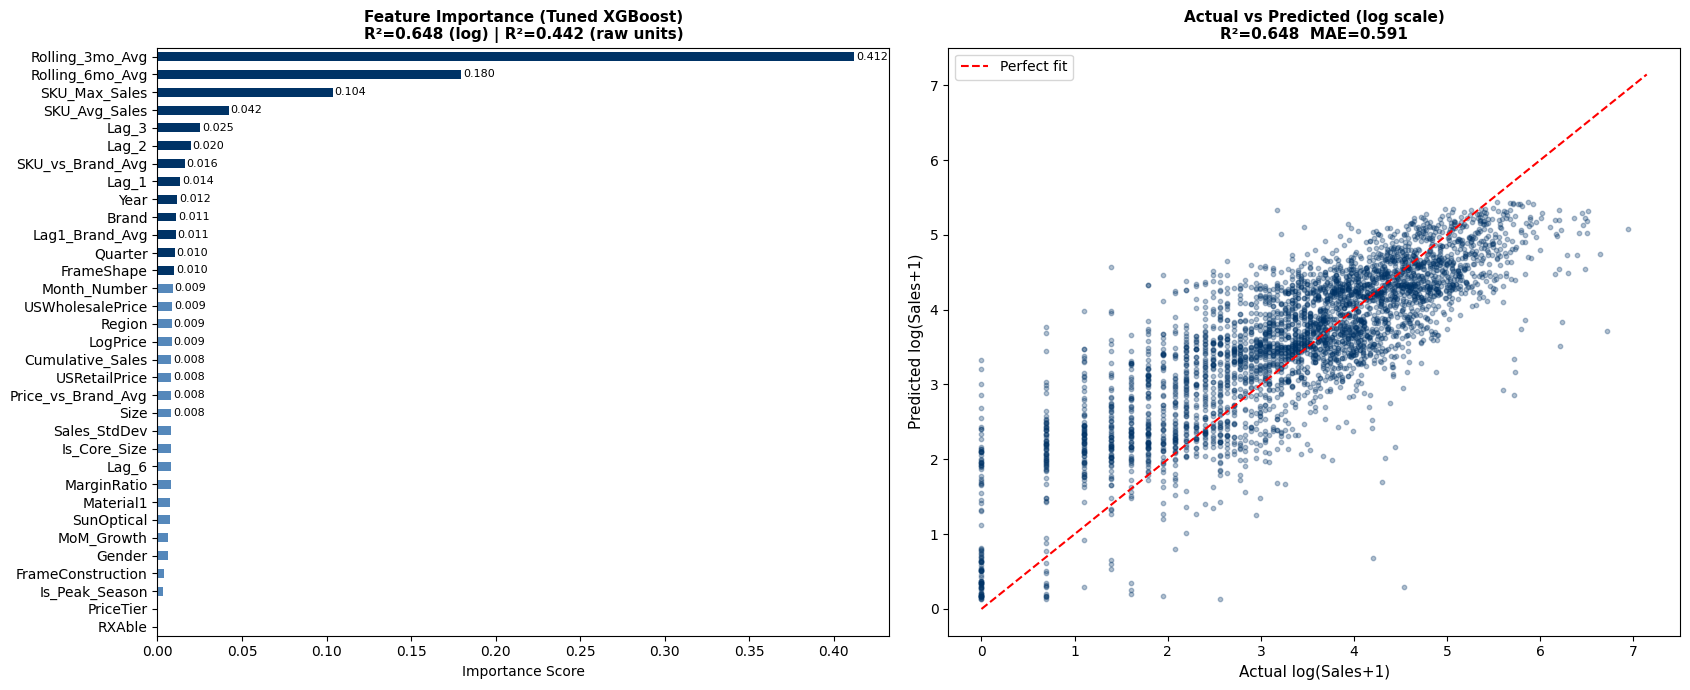

Plot saved to xgboost_finetuned_results.png


In [ ]:
feat_imp = pd.Series(
    best_model.feature_importances_, index=feature_names
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Feature importance bar chart
colors = ['#003366' if v >= feat_imp.quantile(0.6) else '#5588BB' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title(
    f'Feature Importance (Tuned XGBoost)\n'
    f'R²={r2_log:.3f} (log) | R²={r2_raw:.3f} (raw units)',
    fontweight='bold', fontsize=11)
axes[0].set_xlabel('Importance Score')
for i, v in enumerate(feat_imp.values):
    if v > 0.008:
        axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

# Actual vs Predicted on log scale (cleaner view)
axes[1].scatter(y_test_log, final_preds_log, alpha=0.3, color='#003366', s=10)
lims = [0, max(y_test_log.max(), final_preds_log.max()) + 0.2]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual log(Sales+1)', fontsize=11)
axes[1].set_ylabel('Predicted log(Sales+1)', fontsize=11)
axes[1].set_title(
    f'Actual vs Predicted (log scale)\nR²={r2_log:.3f}  MAE={mean_absolute_error(y_test_log, final_preds_log):.3f}',
    fontweight='bold', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.savefig('xgboost_finetuned_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to xgboost_finetuned_results.png')

## CELL 13 — Sample Predictions in Real Units

In [ ]:
sample = pd.DataFrame({
    'Actual (units)':    y_test.values[:20].astype(int),
    'Predicted (units)': final_preds_raw[:20].round(0).astype(int),
    'Error (units)':     (final_preds_raw[:20] - y_test.values[:20]).round(0).astype(int),
})
sample['Error %'] = (sample['Error (units)'] / sample['Actual (units)'].clip(1) * 100).round(1)

print('Sample Predictions (first 20 test rows):')
print(sample.to_string(index=False))

print(f'\n{"="*60}')
print(f'  FINAL SUMMARY')
print(f'{"="*60}')
print(f'  Primary metric  R² (log scale) : {r2_log:.4f}')
print(f'  Secondary metric R² (raw units): {r2_raw:.4f}')
print(f'  MAE  : {mae:.1f} units average error')
print(f'  RMSE : {rmse:.1f} units')
print(f'  MAPE : {mape:.1f}%  (excl. zero-sales months)')
print(f'  Features: {X_train.shape[1]}')
print(f'  Train rows: {len(X_train)} | Test rows: {len(X_test)}')
print(f'{"="*60}')

Sample Predictions (first 20 test rows):
 Actual (units)  Predicted (units)  Error (units)  Error %
              0                  1              1    100.0
              0                  1              1    100.0
              0                  1              1    100.0
             47                 38             -9    -19.1
             47                 35            -12    -25.5
             67                 45            -22    -32.8
             28                 40             12     42.9
            102                 43            -59    -57.8
             96                 31            -65    -67.7
             49                 45             -4     -8.2
            150                 47           -103    -68.7
             33                 18            -15    -45.5
             50                 22            -28    -56.0
             27                 23             -4    -14.8
             32                 25             -7    -21.9
             52

In [ ]:
import os
print(os.getcwd())
print(os.listdir("."))

/content
['.config', 'final_demand.csv', 'detailed_attributes.csv', 'xgboost_finetuned_results.png', 'cluster_detailed_attributes.csv', 'sample_data']


QUESTIONS

In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor

def wape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom if denom != 0 else np.nan

In [ ]:
demand_df = pd.read_csv("final_demand.csv")
attr_df   = pd.read_csv("detailed_attributes.csv")

month_cols = [c for c in demand_df.columns if re.match(r"^\d{2}/\d{4}$", str(c))]
print("Month columns:", month_cols)

id_cols = [c for c in demand_df.columns if c not in month_cols and c not in ["Total"]]

long_df = demand_df.melt(
    id_vars=id_cols,
    value_vars=month_cols,
    var_name="Month",
    value_name="Demand"
)

# Parse Month to datetime
long_df["Month_dt"] = pd.to_datetime("01/" + long_df["Month"], format="%d/%m/%Y")
long_df["MonthNum"] = long_df["Month_dt"].dt.month
long_df["Year"]     = long_df["Month_dt"].dt.year
long_df["Quarter"]  = long_df["Month_dt"].dt.quarter

# Merge attributes
long_df = long_df.drop(columns=[c for c in attr_df.columns if c in long_df.columns and c != "StyleCode"], errors="ignore")
long_df = long_df.merge(attr_df, on="StyleCode", how="left")

print("Long format shape:", long_df.shape)
long_df.head()

Month columns: ['09/2023', '10/2023', '11/2023', '12/2023', '01/2024', '02/2024', '03/2024', '04/2024', '05/2024', '06/2024', '07/2024', '08/2024']
Long format shape: (17568, 21)


,Collection,Brand,Macro Region|Orig. Req. Deliv. Month/Year,StyleCode,Size,ColorDescription,Month,Demand,Month_dt,MonthNum,...,Quarter,FrameConstruction,FrameShape,RXAble,Gender,SunOptical,Material1,Material2,USRetailPrice,USWholesalePrice
0,KC,CALVIN KLEIN SUN,AMER,CK20541S,57.0,BLACK,09/2023,26.0,2023-09-01,9,...,3,Full Rim,Round,True,Unisex,Sun,Acetate,Acetate,190.0,95.0
1,KC,CALVIN KLEIN SUN,EMEA,CK20541S,57.0,BLACK,09/2023,10.0,2023-09-01,9,...,3,Full Rim,Round,True,Unisex,Sun,Acetate,Acetate,190.0,95.0
2,KC,CALVIN KLEIN SUN,AMER,CK20541S,57.0,DARK TOR,09/2023,33.0,2023-09-01,9,...,3,Full Rim,Round,True,Unisex,Sun,Acetate,Acetate,190.0,95.0
3,KC,CALVIN KLEIN SUN,EMEA,CK20541S,57.0,DARK TOR,09/2023,21.0,2023-09-01,9,...,3,Full Rim,Round,True,Unisex,Sun,Acetate,Acetate,190.0,95.0
4,KC,CALVIN KLEIN SUN,AMER,CK20541S,57.0,CRYSTAL,09/2023,11.0,2023-09-01,9,...,3,Full Rim,Round,True,Unisex,Sun,Acetate,Acetate,190.0,95.0


In [ ]:
# Time split
train_cutoff = pd.to_datetime("2024-06-01")  # Train < Jun 2024
train_mask = long_df["Month_dt"] < train_cutoff
valid_mask = long_df["Month_dt"] >= train_cutoff

train_df = long_df.loc[train_mask].copy()
valid_df = long_df.loc[valid_mask].copy()

print("Train months:", train_df["Month"].unique())
print("Valid months:", valid_df["Month"].unique())
print("Train rows:", train_df.shape, "Valid rows:", valid_df.shape)

Train months: ['09/2023' '10/2023' '11/2023' '12/2023' '01/2024' '02/2024' '03/2024'
 '04/2024' '05/2024']
Valid months: ['06/2024' '07/2024' '08/2024']
Train rows: (13176, 21) Valid rows: (4392, 21)


In [ ]:
target_col = "Demand"

# - Keeping Brand/Collection as features
# - StyleCode as feature is usually not meaningful for generalization, so excluded from model features.
exclude_from_features = [
    target_col, "Month_dt", "Month",
]

# Start with all columns, drop excludes
feature_cols = [c for c in long_df.columns if c not in exclude_from_features]

if "StyleCode" in feature_cols:
    feature_cols.remove("StyleCode")

X_train_raw = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_valid_raw = valid_df[feature_cols].copy()
y_valid = valid_df[target_col].copy()

X_train = pd.get_dummies(X_train_raw, dummy_na=True)
X_valid = pd.get_dummies(X_valid_raw, dummy_na=True)

# Align columns (important after get_dummies)
X_train, X_valid = X_train.align(X_valid, join="left", axis=1, fill_value=0)

print("X_train:", X_train.shape, "X_valid:", X_valid.shape)

X_train: (13176, 282) X_valid: (4392, 282)


In [ ]:
import numpy as np
import pandas as pd

def finite_check(name, s):
    s = pd.Series(s)
    print(f"\n{name}:")
    print("  dtype:", s.dtype)
    print("  NaN:", s.isna().sum())
    print("  +inf:", np.isposinf(s).sum())
    print("  -inf:", np.isneginf(s).sum())
    print("  min:", np.nanmin(s.values))
    print("  max:", np.nanmax(s.values))

finite_check("y_train", y_train)
finite_check("y_valid", y_valid)


y_train:
  dtype: float64
  NaN: 2416
  +inf: 0
  -inf: 0
  min: 1.0
  max: 1227.0

y_valid:
  dtype: float64
  NaN: 147
  +inf: 0
  -inf: 0
  min: 1.0
  max: 1035.0


In [ ]:
# After melting to long_df
long_df["Demand"] = pd.to_numeric(long_df["Demand"], errors="coerce")

# treat missing demand as 0 sales
long_df["Demand"] = long_df["Demand"].fillna(0)

long_df["Demand"] = long_df["Demand"].clip(lower=0)

In [ ]:
# Use log target safely
y_train = np.log1p(train_df["Demand"].values)
y_valid = np.log1p(valid_df["Demand"].values)

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

# 1) Clean X
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
X_valid = X_valid.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

# 2) Clean y
y_train = np.array(y_train)
y_valid = np.array(y_valid)

# Ensure finite labels
train_ok = np.isfinite(y_train)
valid_ok = np.isfinite(y_valid)

X_train2 = X_train.loc[train_ok]
y_train2 = y_train[train_ok]

X_valid2 = X_valid.loc[valid_ok]
y_valid2 = y_valid[valid_ok]

print("Train rows used:", X_train2.shape[0], "Valid rows used:", X_valid2.shape[0])

# 3) Fit model
xgb_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train2, y_train2)

# 4) Predict
pred_valid_log = xgb_model.predict(X_valid2)

# If y is log1p, convert back to units
pred_valid = np.expm1(pred_valid_log)
pred_valid = np.clip(pred_valid, 0, None)

pred_valid[:10]

Train rows used: 10760 Valid rows used: 4245


array([27.488205, 24.993738, 30.068314, 28.523094, 13.660577,  9.47393 ,
       20.7378  , 22.04368 , 24.922794, 20.700573], dtype=float32)

In [ ]:
y_train = np.log1p(train_df["Demand"].values)
y_valid = np.log1p(valid_df["Demand"].values)

In [ ]:
long_df["Demand"] = pd.to_numeric(long_df["Demand"], errors="coerce").fillna(0).clip(lower=0)

In [ ]:
valid_out = valid_df.loc[valid_ok, ["StyleCode","Size","ColorDescription","Month","Month_dt"]].copy()
valid_out["Pred_Demand"] = pred_valid

1a) Order table: StyleCode | Size | ColorDescription | Pred_Monthly | Initial_Order_4mo

In [ ]:

valid_out = valid_df.loc[valid_ok, ["StyleCode", "Size", "ColorDescription", "Month", "Month_dt"]].copy()
valid_out["Pred_Demand"] = pred_valid

order_table = (
    valid_out
    .groupby(["StyleCode", "Size", "ColorDescription"], as_index=False)
    .agg(Pred_Monthly=("Pred_Demand", "mean"))
)

order_table["Initial_Order_4mo"] = np.round(order_table["Pred_Monthly"] * 4).astype(int)
order_table = order_table.sort_values("Initial_Order_4mo", ascending=False)

order_table.head(20)

,StyleCode,Size,ColorDescription,Pred_Monthly,Initial_Order_4mo
257,L2876,55.0,BLACK MATTE,317.974701,1272
236,L2707,53.0,BLUE STEEL/,250.378906,1002
576,NIKE 7246,54.0,CLEAR,234.573532,938
496,NIKE 7057,54.0,MATTE A,221.105087,884
560,NIKE 7170,56.0,FOREST,212.127670,849
436,NIKE 5038,50.0,MATTE N,204.013382,816
581,NIKE 7280,50.0,CLEAR,195.273239,781
582,NIKE 7280,50.0,GUNSMOK,180.685913,723
25,CK20531,54.0,MATTE BLA,178.987137,716
529,NIKE 7125,54.0,MINERAL,177.337692,709


In [ ]:
print("valid_df rows:", len(valid_df))
print("valid_ok True:", valid_ok.sum())
print("pred_valid len:", len(pred_valid))

valid_df rows: 4392
valid_ok True: 4245
pred_valid len: 4245


In [ ]:
order_table.to_csv("initial_order_table_4mo.csv", index=False)

1b) Key features that drive frame sales

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

perm = permutation_importance(
    xgb_model,
    X_valid2,
    y_valid2,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    "Feature": X_valid2.columns,
    "Importance_Mean": perm.importances_mean,
    "Importance_Std": perm.importances_std
}).sort_values("Importance_Mean", ascending=False)

imp_df.head(20)

,Feature,Importance_Mean,Importance_Std
21,Macro Region|Orig. Req. Deliv. Month/Year_AMER,0.229476,0.009402
0,Size,0.226694,0.005840
269,SunOptical_Optical,0.204370,0.006682
5,USRetailPrice,0.074005,0.004627
8,Collection_KO,0.022256,0.001883
22,Macro Region|Orig. Req. Deliv. Month/Year_EMEA,0.021849,0.001872
136,ColorDescription_HAVANA,0.021119,0.001644
156,ColorDescription_MATTE,0.020496,0.002401
93,ColorDescription_CRYST,0.019566,0.000978
273,Material1_BIO INJ-G820,0.018465,0.001577


In [ ]:
def base_feature_name(col):
    if "_" in col:
        return col.split("_")[0]
    return col

imp_df["BaseFeature"] = imp_df["Feature"].apply(base_feature_name)

base_imp = (
    imp_df.groupby("BaseFeature", as_index=False)["Importance_Mean"]
    .sum()
    .sort_values("Importance_Mean", ascending=False)
)

base_imp.head(15)

,BaseFeature,Importance_Mean
2,ColorDescription,0.338126
6,Macro Region|Orig. Req. Deliv. Month/Year,0.251324
12,Size,0.226694
13,SunOptical,0.213896
1,Collection,0.078147
14,USRetailPrice,0.074005
7,Material1,0.036540
4,FrameShape,0.028231
5,Gender,0.008816
3,FrameConstruction,0.005246


In [ ]:
import pandas as pd
import numpy as np

cluster_attr = pd.read_csv("cluster_detailed_attributes.csv")
cluster_attr.head()

,StyleCode,FrameConstruction,FrameShape,RXAble,Gender,SunOptical,Material1,Material2,USRetailPrice,USWholesalePrice,cluster
0,CK19119,Full Rim,Square,True,Female,Optical,Acetate,Acetate,223.0,111.5,3
1,CK19569,Full Rim,Round,True,Unisex,Optical,Acetate,Acetate,295.0,147.5,3
2,CK19573,Full Rim,Rectangle,True,Male,Optical,Acetate,Acetate,180.0,90.0,3
3,CK20527,Full Rim,Square,True,Female,Optical,Acetate,Acetate,158.0,79.0,3
4,CK20531,Full Rim,Rectangle,True,Male,Optical,Acetate,Acetate,126.0,63.0,3


In [ ]:
# Try to detect the cluster label column
possible_cluster_cols = ["Cluster", "cluster", "Segment", "segment", "cluster_label", "ClusterLabel", "SegmentID", "SegmentId"]
cluster_col = next((c for c in possible_cluster_cols if c in cluster_attr.columns), None)

if cluster_col is None:
    raise ValueError(f"Couldn't find a cluster column. Columns available: {cluster_attr.columns.tolist()}")

print("Using cluster column:", cluster_col)

Using cluster column: cluster


In [ ]:
# order_table should already exist from 1A
order_table.columns

Index(['StyleCode', 'Size', 'ColorDescription', 'Pred_Monthly',
       'Initial_Order_4mo'],
      dtype='object')

In [ ]:
# Merge cluster labels onto your SKU-level order table
order_with_cluster = order_table.merge(
    cluster_attr[["StyleCode", cluster_col]].drop_duplicates(),
    on="StyleCode",
    how="left"
)

print("Missing cluster labels:", order_with_cluster[cluster_col].isna().sum())
order_with_cluster.head()

Missing cluster labels: 0


,StyleCode,Size,ColorDescription,Pred_Monthly,Initial_Order_4mo,cluster
0,L2876,55.0,BLACK MATTE,317.974701,1272,3
1,L2707,53.0,BLUE STEEL/,250.378906,1002,3
2,NIKE 7246,54.0,CLEAR,234.573532,938,0
3,NIKE 7057,54.0,MATTE A,221.105087,884,3
4,NIKE 7170,56.0,FOREST,212.127670,849,3


In [ ]:
cluster_summary = (
    order_with_cluster
    .groupby(cluster_col, as_index=False)
    .agg(
        Total_Initial_Order_4mo=("Initial_Order_4mo", "sum"),
        Avg_Pred_Monthly=("Pred_Monthly", "mean"),
        SKU_Count=("StyleCode", "nunique")
    )
    .sort_values("Total_Initial_Order_4mo", ascending=False)
)

# Add share %
total_units = cluster_summary["Total_Initial_Order_4mo"].sum()
cluster_summary["Share_of_Total_Units"] = cluster_summary["Total_Initial_Order_4mo"] / total_units

cluster_summary

,cluster,Total_Initial_Order_4mo,Avg_Pred_Monthly,SKU_Count,Share_of_Total_Units
3,3,71322,56.252964,74,0.530638
1,1,37170,59.567959,39,0.276546
0,0,20934,63.049847,27,0.155750
2,2,3124,15.936019,14,0.023243
4,6,1858,116.130997,1,0.013824


In [ ]:
top_cluster = cluster_summary.iloc[0][cluster_col]
print("Top cluster by next-4-month units:", top_cluster)

top_cluster_skus = (
    order_with_cluster[order_with_cluster[cluster_col] == top_cluster]
    .sort_values("Initial_Order_4mo", ascending=False)
    .head(15)
)

top_cluster_skus[["StyleCode", "Size", "ColorDescription", "Pred_Monthly", "Initial_Order_4mo", cluster_col]]

Top cluster by next-4-month units: 3.0


,StyleCode,Size,ColorDescription,Pred_Monthly,Initial_Order_4mo,cluster
0,L2876,55.0,BLACK MATTE,317.974701,1272,3
1,L2707,53.0,BLUE STEEL/,250.378906,1002,3
3,NIKE 7057,54.0,MATTE A,221.105087,884,3
4,NIKE 7170,56.0,FOREST,212.127670,849,3
6,NIKE 7280,50.0,CLEAR,195.273239,781,3
7,NIKE 7280,50.0,GUNSMOK,180.685913,723,3
8,CK20531,54.0,MATTE BLA,178.987137,716,3
17,NIKE 7056,53.0,MATTE D,147.063400,588,3
16,NIKE 7014,53.0,MATTE D,147.063400,588,3
20,NIKE 7015,55.0,MATTE D,133.684097,535,3


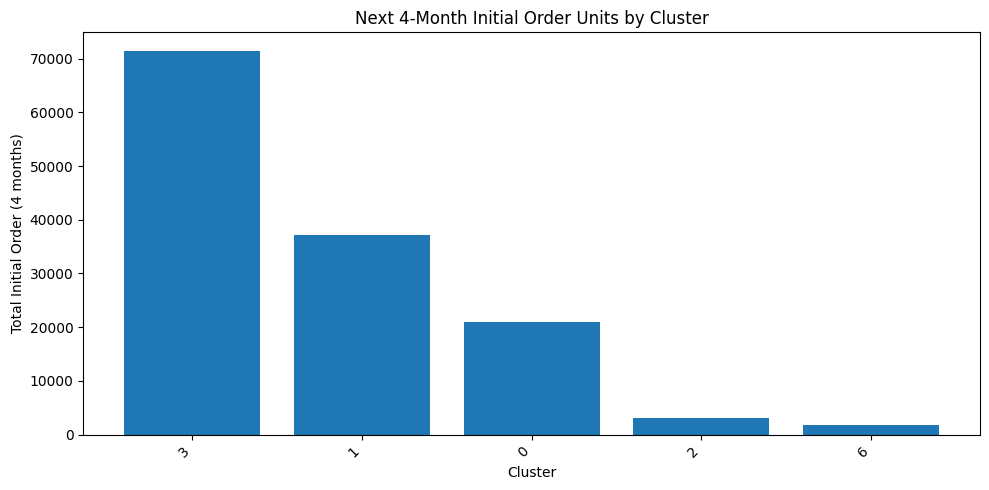

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(cluster_summary[cluster_col].astype(str), cluster_summary["Total_Initial_Order_4mo"])
plt.xticks(rotation=45, ha="right")
plt.title("Next 4-Month Initial Order Units by Cluster")
plt.ylabel("Total Initial Order (4 months)")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()

In [ ]:
order_with_cluster[cluster_col].isna().sum()

np.int64(0)

In [ ]:
total_from_orders = order_with_cluster["Initial_Order_4mo"].sum()
total_from_clusters = cluster_summary["Total_Initial_Order_4mo"].sum()

print(total_from_orders, total_from_clusters, total_from_orders == total_from_clusters)

134408 134408 True


In [ ]:
cluster_summary.head()

,cluster,Total_Initial_Order_4mo,Avg_Pred_Monthly,SKU_Count,Share_of_Total_Units
3,3,71322,56.252964,74,0.530638
1,1,37170,59.567959,39,0.276546
0,0,20934,63.049847,27,0.155750
2,2,3124,15.936019,14,0.023243
4,6,1858,116.130997,1,0.013824


In [ ]:
cluster_summary.sort_values("SKU_Count", ascending=False)

,cluster,Total_Initial_Order_4mo,Avg_Pred_Monthly,SKU_Count,Share_of_Total_Units
3,3,71322,56.252964,74,0.530638
1,1,37170,59.567959,39,0.276546
0,0,20934,63.049847,27,0.155750
2,2,3124,15.936019,14,0.023243
4,6,1858,116.130997,1,0.013824


In [ ]:
cluster_summary2 = cluster_summary.sort_values("Total_Initial_Order_4mo", ascending=False).copy()
cluster_summary2["Share"] = cluster_summary2["Total_Initial_Order_4mo"] / cluster_summary2["Total_Initial_Order_4mo"].sum()

cluster_summary2

,cluster,Total_Initial_Order_4mo,Avg_Pred_Monthly,SKU_Count,Share_of_Total_Units,Share
3,3,71322,56.252964,74,0.530638,0.530638
1,1,37170,59.567959,39,0.276546,0.276546
0,0,20934,63.049847,27,0.155750,0.155750
2,2,3124,15.936019,14,0.023243,0.023243
4,6,1858,116.130997,1,0.013824,0.013824


In [ ]:

# Merge attributes + cluster onto your predicted order table
order_enriched = (
    order_table
    .merge(attr_df[["StyleCode","Material1","Material2"]].drop_duplicates(), on="StyleCode", how="left")
    .merge(cluster_attr[["StyleCode", cluster_col]].drop_duplicates(), on="StyleCode", how="left")
)

order_enriched.head()

,StyleCode,Size,ColorDescription,Pred_Monthly,Initial_Order_4mo,Material1,Material2,cluster
0,L2876,55.0,BLACK MATTE,317.974701,1272,Acetate,Acetate,3
1,L2707,53.0,BLUE STEEL/,250.378906,1002,Acetate,Acetate,3
2,NIKE 7246,54.0,CLEAR,234.573532,938,Acetate,Acetate,0
3,NIKE 7057,54.0,MATTE A,221.105087,884,BIO INJ-G820,BIO INJ-G820,3
4,NIKE 7170,56.0,FOREST,212.127670,849,BIO INJ-G820,BIO INJ-G820,3


In [ ]:
focus = order_enriched[
    order_enriched["ColorDescription"].str.contains("BLACK MATTE|BLUE STEEL", case=False, na=False)
].sort_values("Initial_Order_4mo", ascending=False)

focus[["StyleCode","Size","ColorDescription","Material1","Material2",cluster_col,"Pred_Monthly","Initial_Order_4mo"]].head(20)

,StyleCode,Size,ColorDescription,Material1,Material2,cluster,Pred_Monthly,Initial_Order_4mo
0,L2876,55.0,BLACK MATTE,Acetate,Acetate,3,317.974701,1272
1,L2707,53.0,BLUE STEEL/,Acetate,Acetate,3,250.378906,1002
187,L2876,53.0,BLACK MATTE,Acetate,Acetate,3,67.413994,270
373,L2707,51.0,BLUE STEEL/,Acetate,Acetate,3,38.538704,154


In [ ]:
cutoff = order_enriched["Initial_Order_4mo"].quantile(0.80)
top_band = order_enriched[order_enriched["Initial_Order_4mo"] >= cutoff]

top_band["Material1"].value_counts().head(10)

,count
Material1,
BIO INJ-G820,65
Acetate,38
Metal,10
Titanium,9


In [ ]:
dominant_cluster = cluster_summary.iloc[0][cluster_col]  # the one with highest total units
cluster_df = order_enriched[order_enriched[cluster_col] == dominant_cluster]

cluster_df["Material1"].value_counts().head(10)

,count
Material1,
Acetate,166
BIO INJ-G820,91
Metal,60


In [ ]:
acetate_share = (cluster_df["Material1"].astype(str).str.contains("ACETATE", case=False, na=False)).mean()
print("Dominant cluster:", dominant_cluster)
print("Acetate share in Material1:", round(acetate_share*100, 2), "%")

Dominant cluster: 3.0
Acetate share in Material1: 52.37 %


In [ ]:
order_enriched["Is_Acetate"] = order_enriched["Material1"].astype(str).str.contains("ACETATE", case=False, na=False)

order_enriched.groupby("Is_Acetate").agg(
    Avg_Pred_Monthly=("Pred_Monthly","mean"),
    Avg_Initial_Order=("Initial_Order_4mo","mean"),
    SKU_Count=("StyleCode","nunique")
)

,Avg_Pred_Monthly,Avg_Initial_Order,SKU_Count
Is_Acetate,,,
False,57.331554,229.321622,101
True,51.843689,207.359833,54


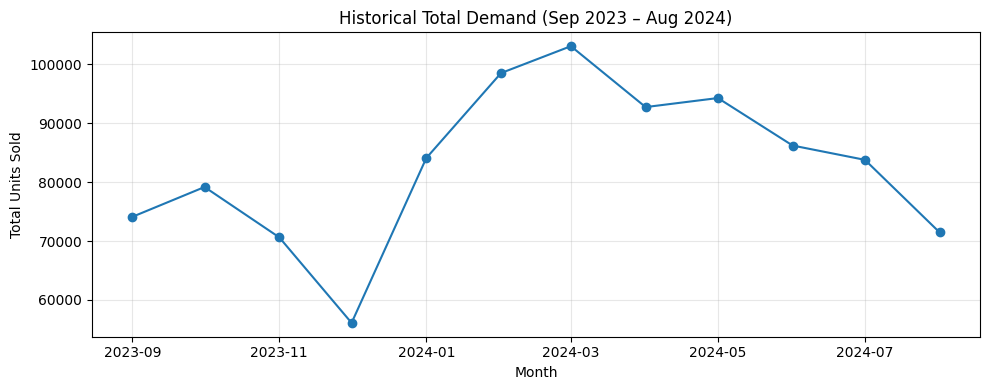

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# Load dataset
demand_df = pd.read_csv("final_demand.csv")

# Identify month columns like "09/2023", ..., "08/2024"
month_cols = [c for c in demand_df.columns if re.match(r"^\d{2}/\d{4}$", str(c))]
month_cols = sorted(month_cols, key=lambda x: pd.to_datetime("01/" + x, format="%d/%m/%Y"))

hist = demand_df[month_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# Total units sold each month (historical)
hist_monthly_total = hist.sum(axis=0)
hist_monthly_total.index = pd.to_datetime(["01/" + m for m in hist_monthly_total.index], format="%d/%m/%Y")

# Plot historical series
plt.figure(figsize=(10,4))
plt.plot(hist_monthly_total.index, hist_monthly_total.values, marker="o")
plt.title("Historical Total Demand (Sep 2023 – Aug 2024)")
plt.ylabel("Total Units Sold")
plt.xlabel("Month")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# valid_out must have: Month_dt, Pred_Demand
# (this is the same object you used for 1A)

pred_monthly_total_series = (
    valid_out.groupby("Month_dt", as_index=False)
    .agg(Pred_Total=("Pred_Demand","sum"))
    .sort_values("Month_dt")
)

pred_monthly_total_series

,Month_dt,Pred_Total
0,2024-06-01,76429.085938
1,2024-07-01,76203.406250
2,2024-08-01,77368.812500


In [ ]:
# Actual totals for the same validation months
actual_valid_totals = (
    long_df.loc[valid_mask]  # same valid_mask you used earlier
    .groupby("Month_dt", as_index=False)
    .agg(Actual_Total=("Demand","sum"))
    .sort_values("Month_dt")
)

compare = pred_monthly_total_series.merge(actual_valid_totals, on="Month_dt", how="left")
compare

,Month_dt,Pred_Total,Actual_Total
0,2024-06-01,76429.085938,86216.0
1,2024-07-01,76203.406250,83785.0
2,2024-08-01,77368.812500,71466.0


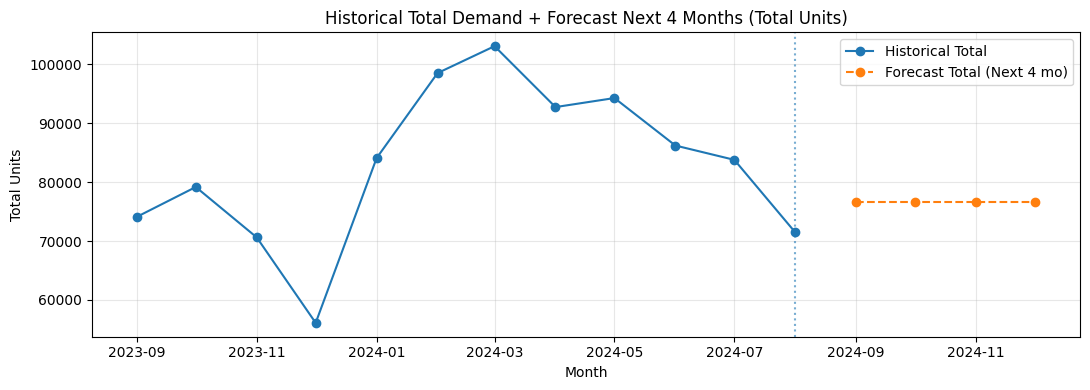

Avg predicted monthly total (from validation months): 76667.0
Forecast total units next 4 months: 306668


In [ ]:
avg_pred_total = compare["Pred_Total"].mean()
future_months = pd.date_range(hist_monthly_total.index.max() + pd.offsets.MonthBegin(1), periods=4, freq="MS")
forecast_4 = [avg_pred_total] * 4

# Plot historical + forecast
plt.figure(figsize=(11,4))
plt.plot(hist_monthly_total.index, hist_monthly_total.values, marker="o", label="Historical Total")
plt.plot(future_months, forecast_4, marker="o", linestyle="--", label="Forecast Total (Next 4 mo)")
plt.axvline(hist_monthly_total.index.max(), linestyle=":", alpha=0.6)
plt.title("Historical Total Demand + Forecast Next 4 Months (Total Units)")
plt.ylabel("Total Units")
plt.xlabel("Month")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Avg predicted monthly total (from validation months):", round(avg_pred_total, 0))
print("Forecast total units next 4 months:", int(round(avg_pred_total * 4)))

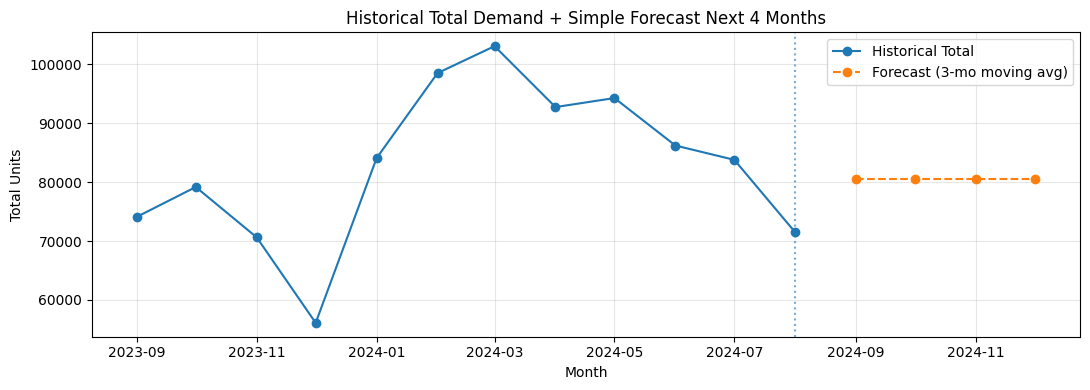

Forecast level (3-month avg): 80489.0


In [ ]:
hist_series = hist_monthly_total.copy()
ma3 = hist_series.rolling(3).mean()

future_months = pd.date_range(hist_series.index.max() + pd.offsets.MonthBegin(1), periods=4, freq="MS")
forecast_level = ma3.iloc[-1]  # last 3-month average
forecast_4 = [forecast_level] * 4

plt.figure(figsize=(11,4))
plt.plot(hist_series.index, hist_series.values, marker="o", label="Historical Total")
plt.plot(future_months, forecast_4, marker="o", linestyle="--", label="Forecast (3-mo moving avg)")
plt.axvline(hist_series.index.max(), linestyle=":", alpha=0.6)
plt.title("Historical Total Demand + Simple Forecast Next 4 Months")
plt.ylabel("Total Units")
plt.xlabel("Month")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Forecast level (3-month avg):", round(forecast_level, 0))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

hist_series = hist_monthly_total.copy()

# Future months: Sep-Dec 2024
future_months = pd.date_range(hist_series.index.max() + pd.offsets.MonthBegin(1), periods=4, freq="MS")

# Baseline: 3-month moving average (last 3 observed months)
baseline_level = hist_series.rolling(3).mean().iloc[-1]
baseline_forecast = np.array([baseline_level] * 4)

baseline_df = pd.DataFrame({"Month": future_months, "Baseline_Forecast": baseline_forecast})
baseline_df

,Month,Baseline_Forecast
0,2024-09-01,80489.0
1,2024-10-01,80489.0
2,2024-11-01,80489.0
3,2024-12-01,80489.0


In [ ]:
# Get Dec 2023 and Sep-Nov 2023 from history
dec_2023 = hist_series.get(pd.Timestamp("2023-12-01"), np.nan)
sep_nov_2023 = hist_series[(hist_series.index >= "2023-09-01") & (hist_series.index <= "2023-11-01")]

uplift_factor = np.nan
if len(sep_nov_2023) > 0 and np.isfinite(dec_2023) and sep_nov_2023.mean() > 0:
    uplift_factor = dec_2023 / sep_nov_2023.mean()

print("Dec 2023 total units:", dec_2023)
print("Avg Sep-Nov 2023 total units:", round(sep_nov_2023.mean(), 2))
print("Baseline historical Dec factor (Dec / avg Sep-Nov):", round(uplift_factor, 3))

Dec 2023 total units: 56105.0
Avg Sep-Nov 2023 total units: 74635.0
Baseline historical Dec factor (Dec / avg Sep-Nov): 0.752


In [ ]:
uplifts = {"Conservative (+10%)": 1.10, "Expected (+20%)": 1.20, "Aggressive (+30%)": 1.30}

scenario_df = baseline_df.copy()

for name, factor in uplifts.items():
    vals = scenario_df["Baseline_Forecast"].values.copy()
    # apply uplift to December to try predicting increase in sales
    for i, m in enumerate(scenario_df["Month"]):
        if m.month == 12:
            vals[i] = vals[i] * factor
    scenario_df[name] = vals

scenario_df

,Month,Baseline_Forecast,Conservative (+10%),Expected (+20%),Aggressive (+30%)
0,2024-09-01,80489.0,80489.0,80489.0,80489.0
1,2024-10-01,80489.0,80489.0,80489.0,80489.0
2,2024-11-01,80489.0,80489.0,80489.0,80489.0
3,2024-12-01,80489.0,88537.9,96586.8,104635.7


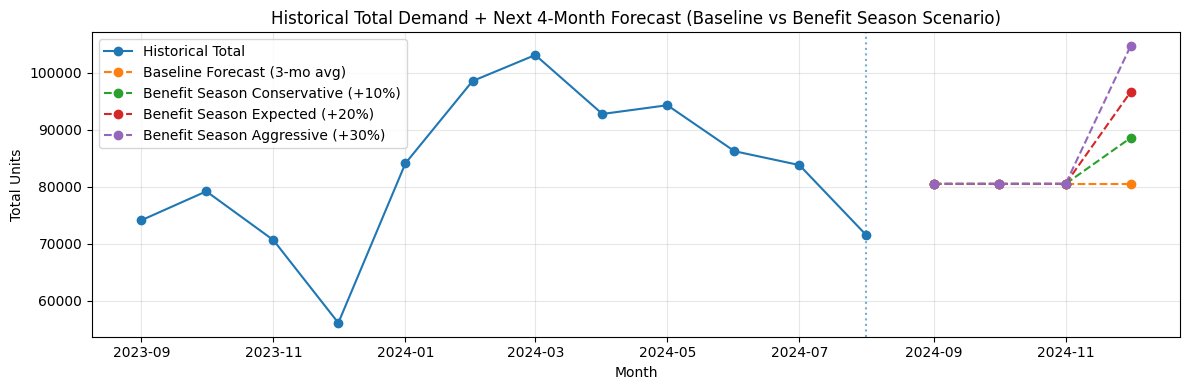

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(hist_series.index, hist_series.values, marker="o", label="Historical Total")

plt.plot(scenario_df["Month"], scenario_df["Baseline_Forecast"], marker="o", linestyle="--", label="Baseline Forecast (3-mo avg)")

for name in uplifts.keys():
    plt.plot(scenario_df["Month"], scenario_df[name], marker="o", linestyle="--", label=f"Benefit Season {name}")

plt.axvline(hist_series.index.max(), linestyle=":", alpha=0.6)
plt.title("Historical Total Demand + Next 4-Month Forecast (Baseline vs Benefit Season Scenario)")
plt.ylabel("Total Units")
plt.xlabel("Month")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()